# RetainIQ — Phase 4.1: Analytical Dataset & Exploratory Data Analysis

## Objective

In this notebook, I pull the analytical dataset directly from MySQL and establish the descriptive
baseline for churn analysis.

I will examine customer population, target balance, tenure, charges, revenue, contract,
payment behavior, service adoption, satisfaction, value, and numeric relationships.

## 1. Connect to MySQL

In [1]:
from getpass import getpass

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
from mysql.connector import Error
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

MYSQL_CONFIG = {
    "host": "localhost",
    "port": 3306,
    "user": "retainiq_user",
    "password": getpass("Enter MySQL password for retainiq_user: "),
    "database": "retainiq"
}

def get_connection():
    return mysql.connector.connect(**MYSQL_CONFIG)

def run_query(query, params=None):
    connection = None
    cursor = None
    try:
        connection = get_connection()
        cursor = connection.cursor(dictionary=True)
        cursor.execute(query, params or ())
        return pd.DataFrame(cursor.fetchall())
    except Error as exc:
        raise RuntimeError(f"MySQL query failed: {exc}") from exc
    finally:
        if cursor:
            cursor.close()
        if connection and connection.is_connected():
            connection.close()

print("MySQL analytical connection is ready.")

MySQL analytical connection is ready.


## 2. Build the Analytical Dataset

In [2]:
eda_query = '''
SELECT
    f.customer_id,
    f.tenure_months,
    f.monthly_charge,
    f.total_charges,
    f.total_refunds,
    f.total_revenue,
    f.satisfaction_score,
    f.churn_score,
    f.cltv,
    f.churn_label,
    f.customer_status,
    d.gender,
    d.age,
    d.under_30,
    d.senior_citizen,
    d.married,
    d.dependents,
    d.number_of_dependents,
    l.country,
    l.state,
    l.city,
    l.zip_code,
    l.latitude,
    l.longitude,
    l.population,
    a.quarter,
    a.referred_a_friend,
    a.number_of_referrals,
    a.offer,
    a.contract,
    a.paperless_billing,
    a.payment_method,
    a.total_extra_data_charges,
    a.total_long_distance_charges,
    s.phone_service,
    s.multiple_lines,
    s.internet_service,
    s.internet_type,
    s.online_security,
    s.online_backup,
    s.device_protection_plan,
    s.premium_tech_support,
    s.streaming_tv,
    s.streaming_movies,
    s.streaming_music,
    s.unlimited_data,
    s.avg_monthly_long_distance_charges,
    s.avg_monthly_gb_download
FROM fact_customer_status f
JOIN dim_demographics d ON f.customer_id = d.customer_id
JOIN dim_location l ON f.customer_id = l.customer_id
JOIN dim_account a ON f.customer_id = a.customer_id
JOIN dim_services s ON f.customer_id = s.customer_id;
'''

eda_df = run_query(eda_query)
print(f"Loaded analytical dataset: {eda_df.shape[0]:,} rows × {eda_df.shape[1]:,} columns")

Loaded analytical dataset: 7,043 rows × 48 columns


## 3. Validate the MySQL Extract

In [3]:
assert eda_df.shape[0] == 7043
assert eda_df["customer_id"].nunique() == 7043
assert eda_df["customer_id"].is_unique

print("PASS — MySQL extract preserves the customer-level grain.")

PASS — MySQL extract preserves the customer-level grain.


## 4. Schema and Missingness Profile

In [4]:
schema = pd.DataFrame({
    "dtype": eda_df.dtypes.astype(str),
    "missing": eda_df.isna().sum(),
    "missing_pct": (eda_df.isna().mean() * 100).round(2),
    "unique_values": eda_df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

schema

,dtype,missing,missing_pct,unique_values
customer_id,object,0,0.000,7043
tenure_months,int64,0,0.000,72
monthly_charge,object,0,0.000,1585
total_charges,object,0,0.000,6540
total_refunds,object,0,0.000,500
total_revenue,object,0,0.000,6975
satisfaction_score,int64,0,0.000,5
churn_score,int64,0,0.000,81
cltv,int64,0,0.000,3438
churn_label,object,0,0.000,2


## 5. Target Distribution

In [5]:
target = (
    eda_df["churn_label"]
    .value_counts()
    .rename_axis("churn_label")
    .reset_index(name="customers")
)

target["percentage"] = (target["customers"] / len(eda_df) * 100).round(2)
target

,churn_label,customers,percentage
0,No,5174,73.460
1,Yes,1869,26.540


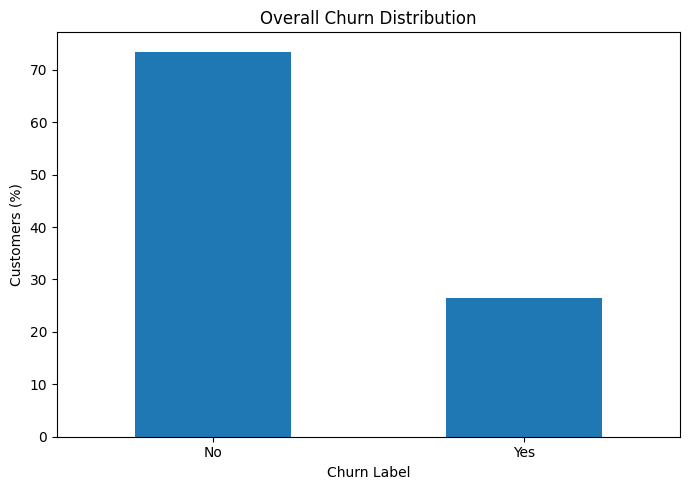

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
target.set_index("churn_label")["percentage"].plot(kind="bar", ax=ax)
ax.set_title("Overall Churn Distribution")
ax.set_xlabel("Churn Label")
ax.set_ylabel("Customers (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Define the Historical Modeling Population

In [7]:
modeling_df = eda_df[
    eda_df["customer_status"].isin(["Stayed", "Churned"])
].copy()

print(f"Historical modeling population: {len(modeling_df):,}")
print(modeling_df["churn_label"].value_counts())

Historical modeling population: 6,589
churn_label
No     4720
Yes    1869
Name: count, dtype: int64


## 7. Tenure by Churn

In [8]:
tenure_summary = (
    modeling_df.groupby("churn_label")["tenure_months"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)
tenure_summary

,count,mean,median,min,max
churn_label,,,,,
No,4720,41.040,42.000,4,72
Yes,1869,17.980,10.000,1,72


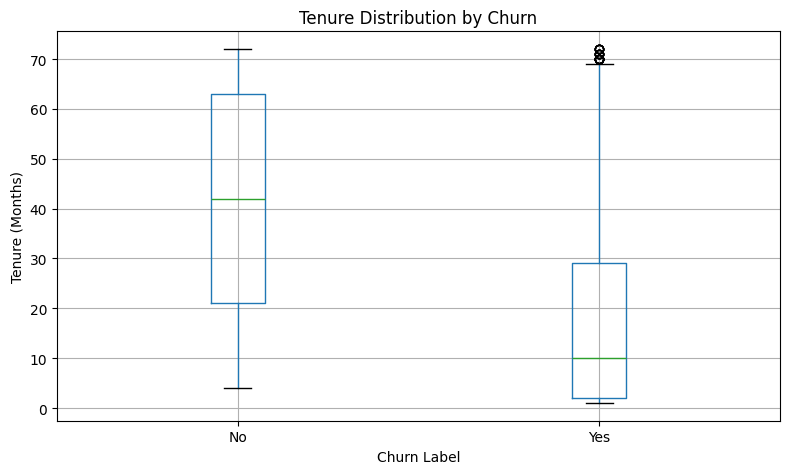

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
modeling_df.boxplot(column="tenure_months", by="churn_label", ax=ax)
ax.set_title("Tenure Distribution by Churn")
ax.set_xlabel("Churn Label")
ax.set_ylabel("Tenure (Months)")
fig.suptitle("")
plt.tight_layout()
plt.show()

## 8. Monthly Charge by Churn

In [10]:
monthly_charge_summary = (
    modeling_df.groupby("churn_label")["monthly_charge"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)
monthly_charge_summary

,mean,median,min,max
churn_label,,,,
No,62.976,66.450,18.25,118.75
Yes,74.441,79.650,18.85,118.35


## 9. Revenue by Churn

In [11]:
revenue_summary = (
    modeling_df.groupby("churn_label")["total_revenue"]
    .agg(["mean", "median", "sum"])
    .round(2)
)
revenue_summary

,mean,median,sum
churn_label,,,
No,"3,735.676","2,960.110",17632392.12
Yes,"1,971.354",893.550,3684459.82


## 10. Contract Churn Rates

In [12]:
contract_churn = pd.crosstab(
    modeling_df["contract"],
    modeling_df["churn_label"],
    normalize="index"
).mul(100).round(2)

contract_churn.sort_values("Yes", ascending=False)

churn_label,No,Yes
contract,,
Month-to-Month,48.310,51.690
One Year,89.120,10.880
Two Year,97.420,2.580


## 11. Payment Method Churn Rates

In [13]:
payment_churn = pd.crosstab(
    modeling_df["payment_method"],
    modeling_df["churn_label"],
    normalize="index"
).mul(100).round(2)

payment_churn.sort_values("Yes", ascending=False)

churn_label,No,Yes
payment_method,,
Mailed Check,58.600,41.400
Bank Withdrawal,64.350,35.650
Credit Card,84.190,15.810


## 12. Internet Type Churn Rates

In [14]:
internet_churn = pd.crosstab(
    modeling_df["internet_type"],
    modeling_df["churn_label"],
    normalize="index"
).mul(100).round(2)

internet_churn.sort_values("Yes", ascending=False)

churn_label,No,Yes
internet_type,,
Fiber Optic,57.870,42.130
Cable,72.480,27.520
DSL,80.030,19.970
No Internet Service,91.590,8.410


## 13. Satisfaction and Churn

In [15]:
satisfaction_churn = (
    modeling_df.groupby("satisfaction_score")["churn_label"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .round(2)
    .rename("churn_rate_pct")
)
satisfaction_churn

satisfaction_score
1   100.000
2   100.000
3    17.110
4     0.000
5     0.000
Name: churn_rate_pct, dtype: float64

## 14. CLTV by Churn

In [16]:
cltv_summary = (
    modeling_df.groupby("churn_label")["cltv"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)
cltv_summary

,mean,median,min,max
churn_label,,,,
No,"4,530.190","4,666.000",2003,6500
Yes,"4,149.410","4,238.000",2003,6484


## 15. Numeric Correlations

In [17]:
numeric_columns = [
    "tenure_months", "monthly_charge", "total_charges",
    "total_refunds", "total_revenue", "satisfaction_score",
    "churn_score", "cltv", "age", "population"
]

corr = modeling_df[numeric_columns].corr()
corr

,tenure_months,monthly_charge,total_charges,total_refunds,total_revenue,satisfaction_score,churn_score,cltv,age,population
tenure_months,1.000,0.205,0.813,0.043,0.841,0.286,-0.290,0.410,-0.010,-0.012
monthly_charge,0.205,1.000,0.648,0.022,0.581,-0.206,0.119,0.093,0.135,0.011
total_charges,0.813,0.648,1.000,0.026,0.970,0.117,-0.166,0.347,0.048,-0.006
total_refunds,0.043,0.022,0.026,1.000,0.023,0.035,-0.021,0.004,0.021,0.020
total_revenue,0.841,0.581,0.970,0.023,1.000,0.147,-0.183,0.361,0.035,-0.010
satisfaction_score,0.286,-0.206,0.117,0.035,0.147,1.000,-0.503,0.098,-0.082,-0.035
churn_score,-0.290,0.119,-0.166,-0.021,-0.183,-0.503,1.000,-0.092,0.079,0.022
cltv,0.410,0.093,0.347,0.004,0.361,0.098,-0.092,1.000,-0.006,0.003
age,-0.010,0.135,0.048,0.021,0.035,-0.082,0.079,-0.006,1.000,-0.023
population,-0.012,0.011,-0.006,0.020,-0.010,-0.035,0.022,0.003,-0.023,1.000


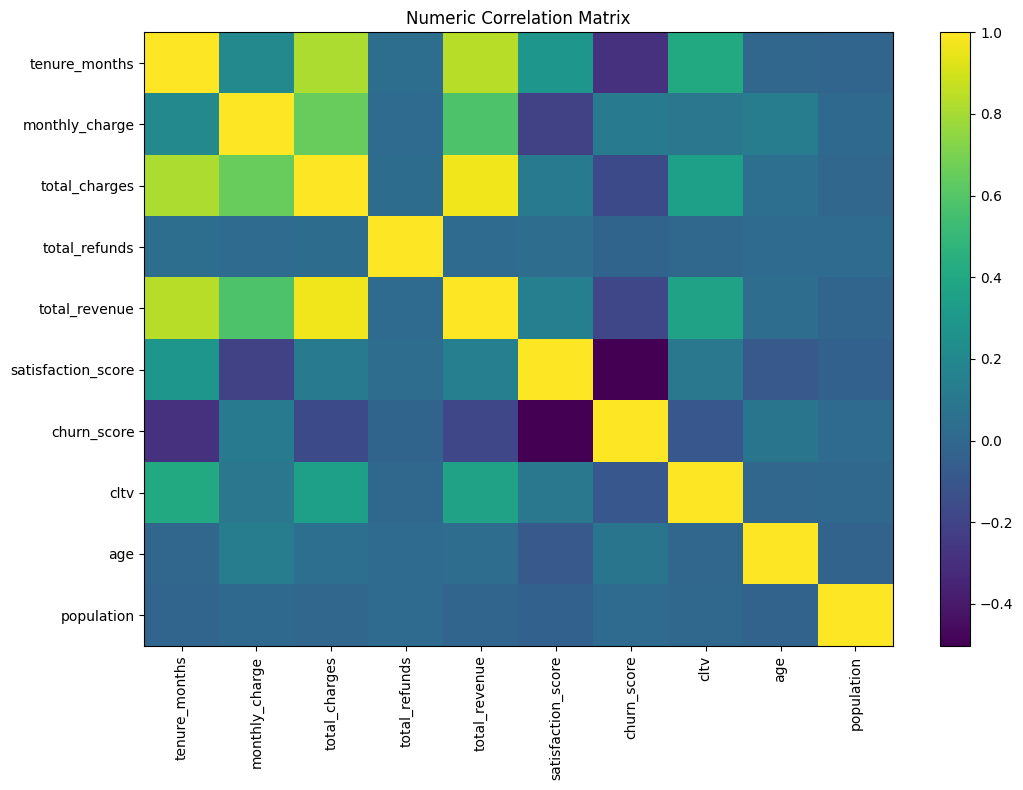

In [18]:
fig, ax = plt.subplots(figsize=(11, 8))
image = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
fig.colorbar(image, ax=ax)
ax.set_title("Numeric Correlation Matrix")
plt.tight_layout()
plt.show()

# Phase 4.1 Conclusion

I built the EDA dataset directly from MySQL and established the descriptive structure of the churn
problem.

I also separated `Stayed`/`Churned` customers from `Joined` customers before modeling.

**Next:** formal hypothesis testing and churn-driver analysis.